In [1]:
"""
Sine Wave Forecasting with LSTM (TensorFlow/Keras)
---------------------------------------------------

This notebook demonstrates training an LSTM to predict the next value of a sine wave
using sequence modeling.

Covers:
- Synthetic sine wave generation
- Sequence preparation
- Batch generator setup
- LSTM model training
- Loss visualization
"""


'\nSine Wave Forecasting with LSTM (TensorFlow/Keras)\n---------------------------------------------------\n\nThis notebook demonstrates training an LSTM to predict the next value of a sine wave\nusing sequence modeling.\n\nCovers:\n- Synthetic sine wave generation\n- Sequence preparation\n- Batch generator setup\n- LSTM model training\n- Loss visualization\n'

In [2]:
# Basic Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping

# Sklearn Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score,
    mean_squared_error, root_mean_squared_error
)

# TensorFlow GPU/CPU Config

# Enable memory growth for GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

# Configure threading
tf.config.threading.set_intra_op_parallelism_threads(32)
tf.config.threading.set_inter_op_parallelism_threads(32)


2025-04-26 07:00:43.375307: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-26 07:00:43.382746: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745676043.391195 1624945 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745676043.393795 1624945 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745676043.401106 1624945 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

GPU memory growth enabled


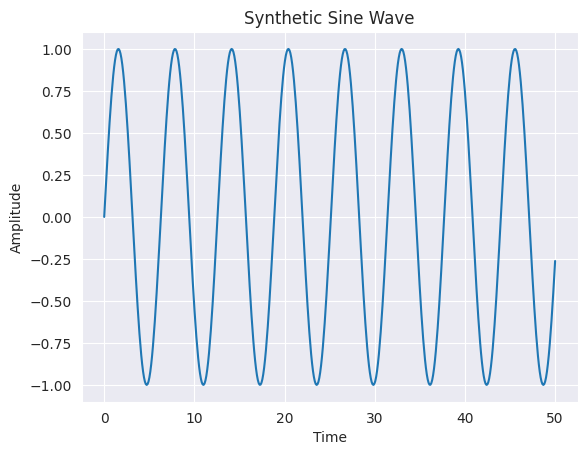

In [3]:

# Create time series
time = np.linspace(0, 50, 500)  # 500 points
sine_wave = np.sin(time)

df = pd.DataFrame({'time': time, 'sine_wave': sine_wave})

# Plot sine wave
plt.plot(time, sine_wave)
plt.title('Synthetic Sine Wave')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()


In [4]:

# 80% train, 20% test
split_point = int(len(df) * 0.8)
train_data = df.iloc[:split_point]
test_data = df.iloc[split_point:]


In [5]:

def create_sequences(data, sequence_length):
    sequences, labels = [], []
    for i in range(len(data) - sequence_length):
        sequence = data[i:i+sequence_length]
        label = data[i+sequence_length]
        sequences.append(sequence)
        labels.append(label)
    return np.array(sequences), np.array(labels)

sequence_length = 10
train_sequences, train_labels = create_sequences(train_data['sine_wave'].values, sequence_length)
test_sequences, test_labels = create_sequences(test_data['sine_wave'].values, sequence_length)

print(f"Training Sequences Shape: {train_sequences.shape}")
print(f"Testing Sequences Shape: {test_sequences.shape}")


Training Sequences Shape: (390, 10)
Testing Sequences Shape: (90, 10)


In [6]:

def batch_generator(X, y, batch_size=32):
    size = len(X)
    indices = np.arange(size)
    np.random.shuffle(indices)
    while True:
        for start in range(0, size, batch_size):
            batch_indices = indices[start:start + batch_size]
            batch_X = X[batch_indices].reshape(-1, sequence_length, 1)
            batch_y = y[batch_indices]
            yield batch_X, batch_y

batch_size = 32
train_gen = batch_generator(train_sequences, train_labels, batch_size)

# Example batch
batch_X, batch_y = next(train_gen)
print(f"Batch X shape: {batch_X.shape}")
print(f"Batch y shape: {batch_y.shape}")


Batch X shape: (32, 10, 1)
Batch y shape: (32,)


In [7]:

model = Sequential([
    LSTM(50, input_shape=(sequence_length, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')


I0000 00:00:1745676044.931905 1624945 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 866 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:01:00.0, compute capability: 8.6
/mnt/mls/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:

history = model.fit(
    train_gen,
    steps_per_epoch=len(train_sequences) // batch_size,
    epochs=10,
    validation_data=(test_sequences.reshape(-1, sequence_length, 1), test_labels)
)


Epoch 1/10


I0000 00:00:1745676046.211880 1625288 cuda_dnn.cc:529] Loaded cuDNN version 90800


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.4505 - val_loss: 0.2197
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1815 - val_loss: 0.1198
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1112 - val_loss: 0.1019
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0924 - val_loss: 0.0898
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0831 - val_loss: 0.0791
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0706 - val_loss: 0.0641
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0561 - val_loss: 0.0487
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0431 - val_loss: 0.0317
Epoch 9/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0254 - val_loss: 0.0133
Epoch 10/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0098 - val_loss: 0.0017


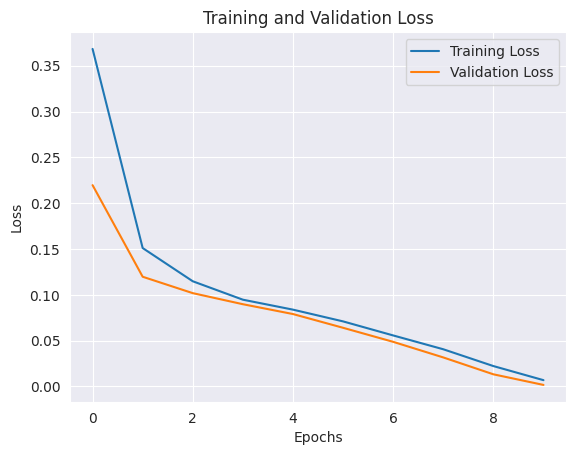

In [9]:

train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()
